In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA



from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [ ]:
df = load_breast_cancer(as_frame=True).frame
df.shape


(569, 31)

In [ ]:
X = df.drop('target',axis=1)
y = df['target']

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
np.set_printoptions(suppress=True)

pca_full = PCA(n_components=None)

X_pca_full = pca_full.fit_transform(X_scaled)

explained = pca_full.explained_variance_ratio_

explained

array([0.4427, 0.1897, 0.0939, 0.066 , 0.055 , 0.0402, 0.0225, 0.0159,
       0.0139, 0.0117, 0.0098, 0.0087, 0.008 , 0.0052, 0.0031, 0.0027,
       0.002 , 0.0018, 0.0016, 0.001 , 0.001 , 0.0009, 0.0008, 0.0006,
       0.0005, 0.0003, 0.0002, 0.0001, 0.    , 0.    ])

In [ ]:
cum_variance = np.cumsum(explained)

cum_variance

array([0.4427, 0.6324, 0.7264, 0.7924, 0.8473, 0.8876, 0.9101, 0.926 ,
       0.9399, 0.9516, 0.9614, 0.9701, 0.9781, 0.9834, 0.9865, 0.9892,
       0.9911, 0.9929, 0.9945, 0.9956, 0.9966, 0.9975, 0.9983, 0.9989,
       0.9994, 0.9997, 0.9999, 1.    , 1.    , 1.    ])

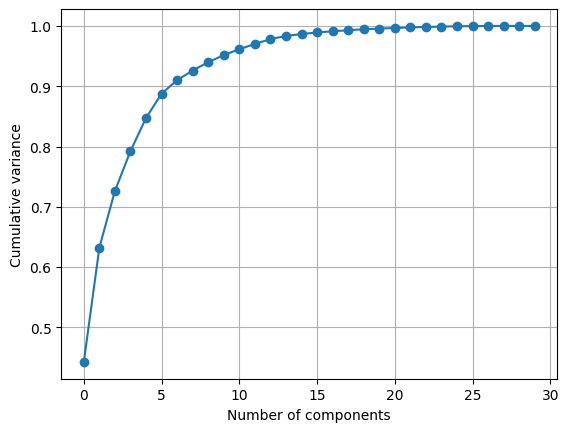

In [ ]:
plt.plot(cum_variance, marker='o')
plt.xlabel("Number of components")
plt.ylabel("Cumulative variance")
plt.grid()
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Pipeline WITHOUT PCA: Scale -> Logistic Regression
pipe_no_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=500))
])

pipe_no_pca.fit(X_train, y_train)
pred_no_pca = pipe_no_pca.predict(X_test)

acc_no_pca = accuracy_score(y_test, pred_no_pca)

In [ ]:
print("Accuracy (No PCA):", acc_no_pca)

Accuracy (No PCA): 0.9824561403508771


In [ ]:
pipe_with_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=10)),
    ("clf", LogisticRegression(max_iter=500))
])

pipe_with_pca.fit(X_train, y_train)
pred_with_pca = pipe_with_pca.predict(X_test)

acc_with_pca = accuracy_score(y_test, pred_with_pca)
acc_with_pca

0.9736842105263158


### Explaination of the Results

If PCA accuracy is similar:
- Great. We reduced dimensions without losing performance.

If PCA accuracy is better:
- PCA likely removed redundancy/noise that was confusing the model.

If PCA accuracy is worse:
- We removed useful information.
- Increase the threshold (for example, 0.98), or skip PCA.

Bottom line:
PCA is a tool. Use it when it matches the problem conditions.
